# Amsterdam personal weather stations

134 Netatmo stations in and around Amsterdam, May 2016 - May 2018, 5-minute
rainfall: de Vos et al. (2019),
[doi:10.1029/2019GL083731](https://doi.org/10.1029/2019GL083731), data at
[4TU](https://data.4tu.nl/articles/dataset/Rainfall_observations_datasets_from_Personal_Weather_Stations/12703250),
CC BY 4.0. It is the dataset the PWSQC filters were built on.

The reference is not a gauge network: it is 20 pixels of the KNMI
gauge-adjusted radar product, hourly, used as pseudo-gauges.

The example folder
([`AMS_PWS/`](https://github.com/OpenSenseAction/opensense_example_data/tree/main/AMS_PWS))
also holds `PWS_example_dataset.ipynb`, which builds the NetCDF from the
original CSV files; this notebook starts from the NetCDF.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import poligrain as plg

from core import viz_style as vs
from core.opensense import example_data, plots

vs.use_style()
C1, C2, C3 = (vs.SERIES[k] for k in vs.SERIES_ORDER)

In [2]:
data = example_data.load("ams_pws", "full_period", verbose=False)
pws, ref = data["pws"], data["gauge"]
pws

<xarray.Dataset> Size: 237MB
Dimensions:    (time: 219168, id: 134)
Coordinates:
  * time       (time) datetime64[ns] 2MB 2016-05-01T00:05:00 ... 2018-06-01
  * id         (id) <U6 3kB 'ams1' 'ams2' 'ams3' ... 'ams132' 'ams133' 'ams134'
    elevation  (id) float64 1kB nan nan nan nan nan nan ... nan nan nan nan nan
    lat        (id) float64 1kB 52.31 52.3 52.31 52.35 ... 52.43 52.3 52.26
    lon        (id) float64 1kB 4.671 4.675 4.677 4.678 ... 5.036 5.041 5.045
    x          (id) float64 1kB 6.139e+05 6.142e+05 ... 6.392e+05 6.396e+05
    y          (id) float64 1kB 5.796e+06 5.796e+06 ... 5.797e+06 5.792e+06
Data variables:
    rainfall   (id, time) float64 235MB 0.0 0.0 0.0 0.0 0.0 ... nan 0.0 0.0 0.0
Attributes:
    title:                 PWS data from Amsterdam
    file author:           Maximilian Graf
    institution:           Wageningen University and Research, Department of ...
    date:                  2022-10-18 10:32:00
    source:                Netamo PWS
    history:               Data derived and reformated from the originally pu...
    naming convention:     OpenSense-0.1
    license restrictions:  CC-BY 4.0 https://creativecommons.org/licenses/by/...
    reference:             https://doi.org/10.1029/2019GL083731
    comment:

## Two time steps, two variable names

The PWS file is on OpenSense-0.1 naming: the per-step amount is `rainfall`,
not `rainfall_amount`. PWS are 5-minute, the radar reference hourly. The
`R` that `load()` adds would need `rainfall_amount`, so rates are computed
here from the declared step.

In [3]:
from core.opensense.retrieval import sampling_interval_s

for name, ds in (("PWS", pws), ("reference", ref)):
    step = sampling_interval_s(ds.time)
    print(f"{name:10s} step {step / 60:.0f} min, {ds.sizes['id']} stations, "
          f"{float(ds.rainfall.notnull().mean()) * 100:.0f}% of values present, "
          f"naming {ds.attrs.get('naming convention')!r}")

PWS        step 5 min, 134 stations, 69% of values present, naming 'OpenSense-0.1'
reference  step 60 min, 20 stations, 95% of values present, naming 'OpenSense-0.1'


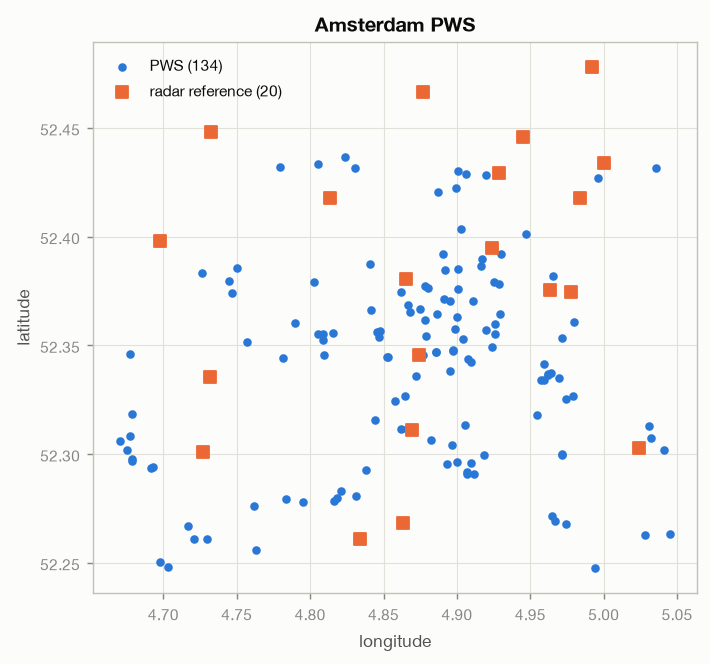

In [4]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(pws.lon, pws.lat, s=14, color=C1, label=f"PWS ({pws.sizes['id']})")
ax.scatter(ref.lon, ref.lat, s=40, color=C2, marker="s", label=f"radar reference ({ref.sizes['id']})")
ax.set(xlabel="longitude", ylabel="latitude", title="Amsterdam PWS")
ax.legend();

## Monthly totals

Median station against median reference pixel, per month. Months where a
station is missing more than a fifth of its steps are left out of its median.

PWS / reference over the whole record: 0.84


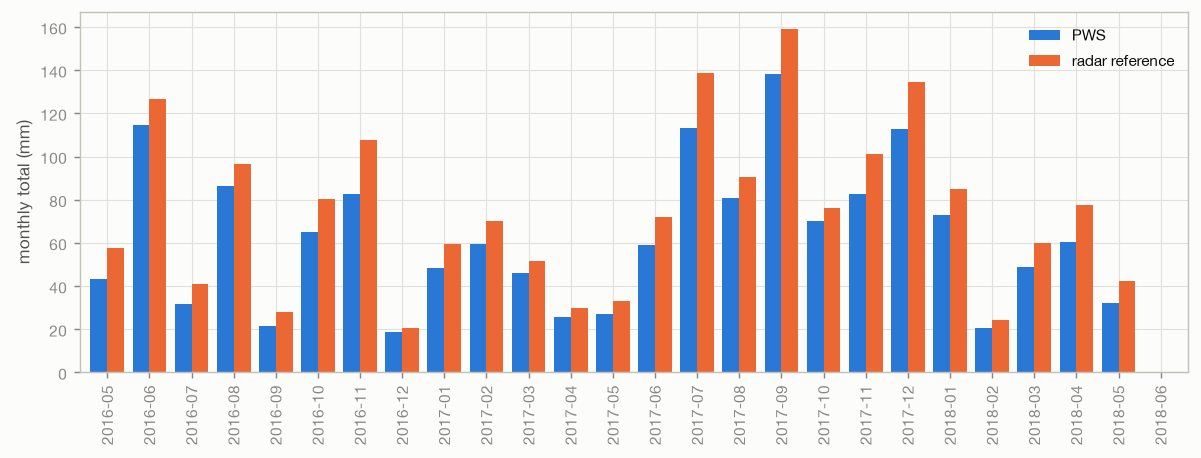

In [5]:
def monthly(ds, max_missing=0.2):
    total = ds.rainfall.resample(time="MS").sum()
    present = ds.rainfall.notnull().resample(time="MS").mean()
    return total.where(present >= 1 - max_missing).median("id").to_series()

months = pd.DataFrame({"PWS": monthly(pws), "radar reference": monthly(ref)})
print(f"PWS / reference over the whole record: {months.PWS.sum() / months['radar reference'].sum():.2f}")
fig, ax = plt.subplots(figsize=(11, 3.6))
months.plot.bar(ax=ax, color=[C1, C2], width=0.8)
ax.set_xticklabels([f"{t:%Y-%m}" for t in months.index], rotation=90)
ax.set(ylabel="monthly total (mm)", xlabel="");

## Quality control, August 2016

The station-outlier filter compares each station with its neighbours over a
28-day window, so it can only judge a step once it has 28 days of history.
QC therefore runs on July and August, and August is inspected. It takes
about a minute.

In [6]:
from core.opensense import pws_qc

qc = pws_qc.flag(pws.sel(time=slice("2016-07", "2016-08"))).sel(time="2016-08")
table = pws_qc.summary(qc)
usable = pws_qc.usable(qc)
print(f"{len(usable)} of {qc.sizes['id']} stations usable as references")
print(f"median station total: {table.total_mm.median():.1f} mm before QC, "
      f"{table.total_qc_mm.median():.1f} mm after")
table.sort_values("total_mm").tail(5).round(3)

71 of 134 stations usable as references
median station total: 62.9 mm before QC, 60.6 mm after


,missing,fz,hi,so,rate,so_evaluated,total_mm,total_qc_mm
station,,,,,,,,
ams6,0.125,0.0,0.000,0.0,0.0,0.705,128.903,128.903
ams24,0.021,0.0,0.000,0.0,0.0,0.710,137.883,137.883
ams42,0.012,0.0,0.000,0.0,0.0,0.735,151.904,151.904
ams84,0.014,0.0,0.000,0.0,0.0,0.735,162.711,162.711
ams105,0.349,0.0,0.109,0.0,0.0,0.000,56873.403,921.726


One station reports tens of metres of rain in the month. The high-influx
filter removes most of it but not all; the outlier filter cannot judge a
station missing a third of its record; and `usable()` excludes it because it
is flagged too often. A bad station is caught by the combination, not by one
filter.

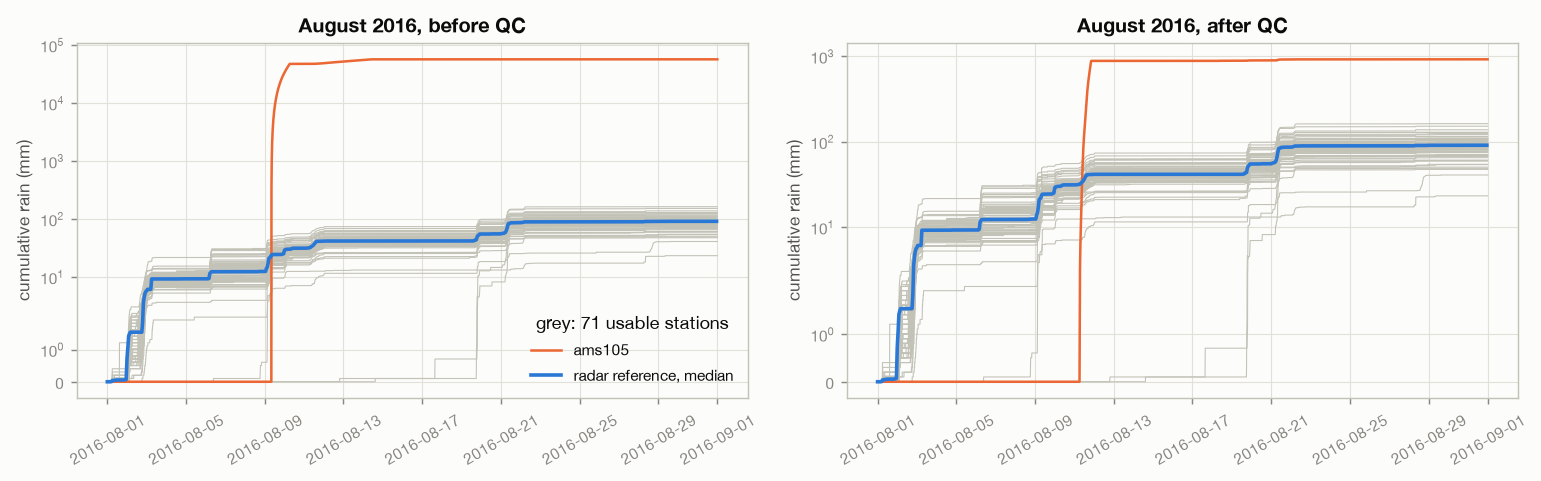

In [7]:
worst = table.total_mm.idxmax()
ref_cum = ref.rainfall.sel(time="2016-08").fillna(0).cumsum("time").median("id")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, var, title in zip(axes, ("rainfall", "rainfall_qc"), ("before QC", "after QC")):
    cum = qc[var].fillna(0).cumsum("time")
    for sid in usable:
        ax.plot(cum.time, cum.sel(id=sid), color=vs.BASELINE, lw=0.6)
    ax.plot(cum.time, cum.sel(id=worst), color=C2, lw=1.4, label=worst)
    ax.plot(ref_cum.time, ref_cum, color=C1, lw=2, label="radar reference, median")
    ax.set(yscale="symlog", ylabel="cumulative rain (mm)", title=f"August 2016, {title}")
    ax.tick_params(axis="x", labelrotation=30)
axes[0].legend(title=f"grey: {len(usable)} usable stations")
fig.tight_layout()